# Published Atari 100k analysis
Analyze SPR, DrQ (epsilon), and IRIS on the exact shared 26-task set. The primary intervals resample runs with tasks fixed; the sensitivity intervals also resample tasks.

In [1]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'examples' / 'atari_analysis.py').exists())
sys.path.insert(0, str(root / 'examples'))
import atari_analysis as atari

## Load and validate published scores
This checks identical task names, the 100/100/5 run counts, finite values, and preservation of all 5,330 scores while applying the published random/human normalization.

In [2]:
games, scores, references_path = atari.load_scores()
{name: values.shape for name, values in scores.items()}

{'SPR': (100, 26), 'DrQ (epsilon)': (100, 26), 'IRIS': (5, 26)}

## Compute and independently check results
All four aggregates, both profile definitions, all three pairwise comparisons, and task-bootstrap sensitivity intervals are computed here. NumPy checks the point estimates independently.

In [3]:
results = atari.analyze(scores)
results['points'], results['comparisons']

({'SPR': array([0.33664932, 0.61579574, 0.39562938, 0.57730175]),
  'DrQ (epsilon)': array([0.27964693, 0.46474125, 0.3129014 , 0.63053412]),
  'IRIS': array([0.50115538, 1.04590658, 0.28879973, 0.51166397])},
 {'IRIS vs SPR': array([0.61042308]),
  'IRIS vs DrQ (epsilon)': array([0.68807692]),
  'DrQ (epsilon) vs SPR': array([0.38298846])})

## Save the reproducibility record and figures
The JSON records task order, hashes, versions, settings, estimates, and intervals. Plotting uses Matplotlib directly.

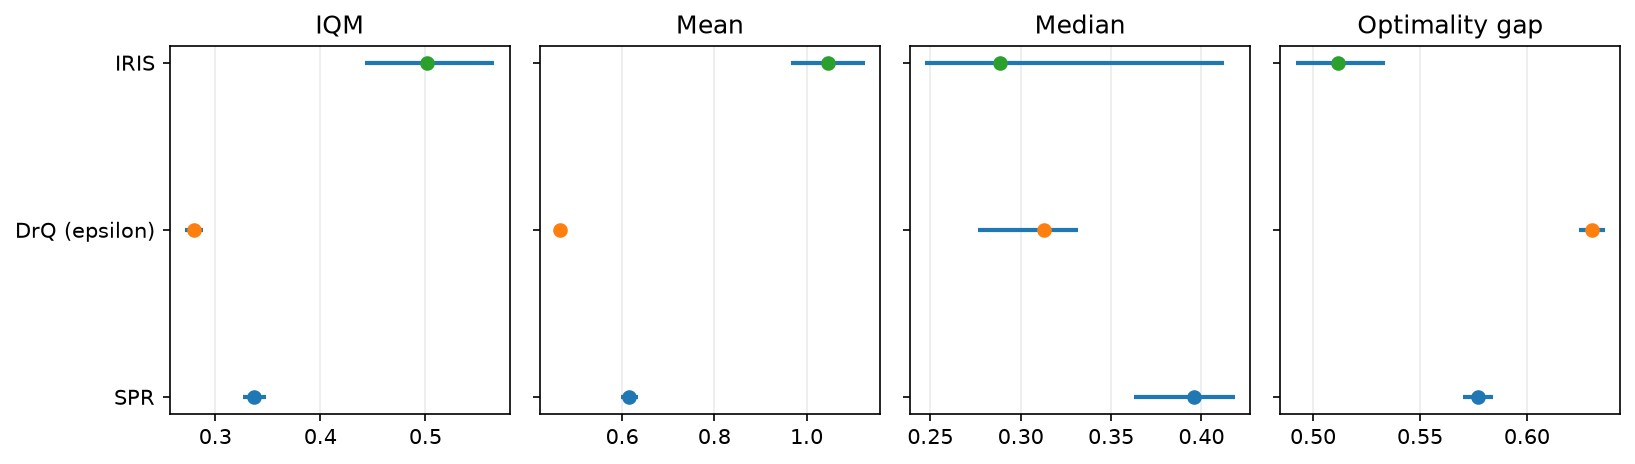

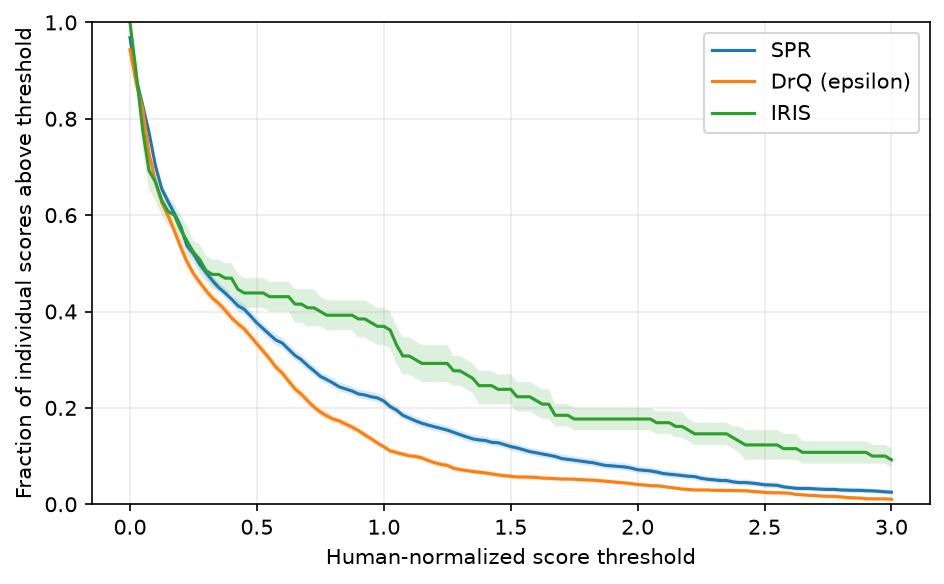

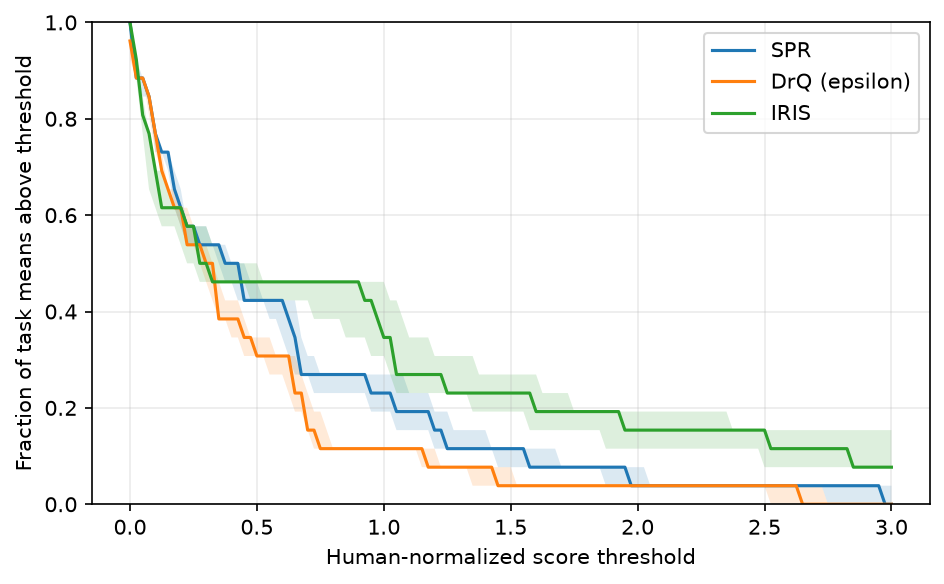

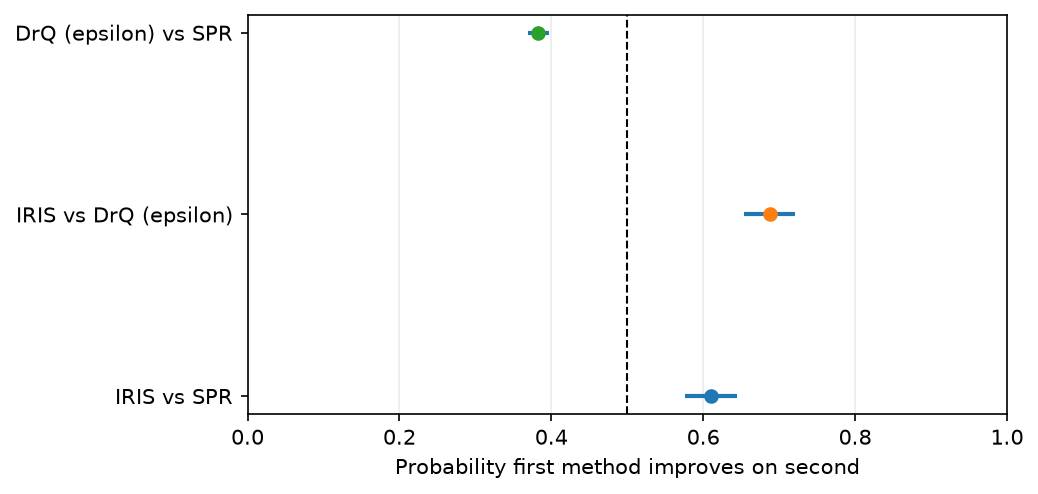

{'SPR.json': '055133e22ddb1e7154bbb48b6d229e3b064ea374911158f5d5c1a92cd59e2ad3',
 'DrQ(eps).json': 'a86f9f4243b7eb3f994b6db4c9c87fb698742bfa08e7b06e414be41abf1f0574',
 'IRIS.json': '40f45fc2b02e4830e90476ab41ada4251682d9ccc8edaa7b8e25f0ec51bafb5f',
 'atari_100k_baselines.json': '8f8f34a7fb3ccd28d28cf8e7d35b24521b82ef606105ff31107d4ec685991523'}

In [4]:
from IPython.display import Image, display
atari.plot_results(results)
record = atari.record_results(games, scores, references_path, results)
for name in ('metrics.png', 'profiles.png', 'task-mean-profiles.png', 'comparison.png'):
    display(Image(filename=atari.OUTPUT / name))
record['input_sha256']